# MCDI501 — Estadística Computacional para la Toma de Decisiones
## Formativa 2 — Fase 3: Modelamiento Predictivo (Regresión Logística)
### Proyecto Transversal — Práctica guiada de preparación para la Sumativa 3

**Título del proyecto:** Predicción del Abandono Académico en Educación Superior mediante Regresión Logística

| Campo | Detalle |
|:---|:---|
| **Curso** | MCDI501 — Estadística Computacional para la Toma de Decisiones |
| **Docente** | Jean Paul Maidana González |
| **Grupo** | Grupo 7 |
| **Integrantes** | Juan de Dios Díaz Ríos · Francisco Fariña Molina · Constanza Moreno Giacometto · Yenne Sepúlveda Jerez |
| **Fecha** | Julio 2026 |
| **Dataset** | Predict Students' Dropout and Academic Success — UCI Machine Learning Repository |

---

## Índice

1. [Introducción y conexión con las Sumativas 1 y 2](#1-intro)
2. [Configuración del entorno y carga de datos](#2-setup)
3. [Preparación de datos para modelamiento](#3-prep)
   - 3.1 [Hallazgos relevantes de S1 y S2 (insumos del modelo)](#3.1-hallazgos)
   - 3.2 [Tratamiento de valores faltantes](#3.2-faltantes)
   - 3.3 [Definición de la variable objetivo y selección justificada de predictores](#3.3-seleccion)
   - 3.4 [División train/test (70/30) y estandarización](#3.4-split)
4. [Modelo de regresión logística](#4-modelo)
   - 4.1 [Ajuste y resumen del modelo](#4.1-ajuste)
   - 4.2 [Coeficientes, odds ratios y significancia](#4.2-or)
   - 4.3 [Diagnóstico de multicolinealidad (VIF)](#4.3-vif)
   - 4.4 [Comparación de modelos alternativos (AIC/BIC)](#4.4-aicbic)
   - 4.5 [Validación cruzada (K-Fold)](#4.5-cv)
5. [Evaluación de desempeño predictivo](#5-eval)
   - 5.1 [Predicciones y matriz de confusión](#5.1-confusion)
   - 5.2 [Métricas: accuracy, precision, recall y F1](#5.2-metricas)
   - 5.3 [Curva ROC y AUC](#5.3-roc)
6. [Síntesis y reflexión](#6-sintesis)
7. [Referencias](#7-referencias)


<a id='1-intro'></a>
## 1. Introducción y conexión con las Sumativas 1 y 2

Esta actividad formativa ensaya el **flujo completo de modelamiento predictivo** sobre el mismo problema
de las evaluaciones anteriores: el **abandono académico** en educación superior (dataset *Predict Students' Dropout and
Academic Success*, Realinho et al., 2021; **n = 3.630** tras binarizar `Target` en Graduate/Dropout, criterio fijado en S1).

El problema es de **clasificación binaria** — la variable dependiente es categórica (¿el estudiante abandona o no?) —,
por lo que el modelo apropiado es la **regresión logística** (Maidana, 2026a, §2.2). Siguiendo el principio de que la
selección de variables *"nunca debe ser un proceso puramente mecánico"* (Maidana, 2026d, §1), los predictores no se
eligen aquí desde cero: se **heredan de la evidencia acumulada** en S1 (contrastes t de Welch, chi-cuadrado, matriz de
correlaciones) y validada computacionalmente en S2 (bootstrap, permutación, jackknife y análisis de robustez frente a
outliers).

**Flujo de trabajo de este notebook** (Maidana, 2026a, §5): preparación de datos → división train/test **antes** de
cualquier transformación (regla de oro contra *data leakage*; Maidana, 2026b, §6) → ajuste e interpretación del modelo
logístico → diagnóstico de multicolinealidad (VIF) → evaluación honesta del desempeño sobre el conjunto de prueba.


<a id='2-setup'></a>
## 2. Configuración del entorno y carga de datos

Se mantienen los criterios de reproducibilidad de S2: semilla global 42 y verificación de consistencia del dataset
binario (n = 3.630) con S1.


In [1]:
# ============================================================
# IMPORTACIÓN DE LIBRERÍAS Y CONFIGURACIÓN GLOBAL
# Criterios heredados de S1/S2: dataset binario, semilla 42
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                             recall_score, f1_score, roc_curve, roc_auc_score,
                             classification_report)

# ── Estilo gráfico (mismo de S1/S2)
sns.set_theme(style="whitegrid", palette="deep", font_scale=1.05)
plt.rcParams['figure.dpi'] = 100
pd.options.display.float_format = '{:.4f}'.format

SEED = 42            # semilla global (idéntica a S1/S2)
TEST_SIZE = 0.30     # partición exigida: 70% train / 30% test

print(f"numpy {np.__version__} | pandas {pd.__version__} | statsmodels {sm.__version__}")
print(f"Semilla global = {SEED} | Partición train/test = {1-TEST_SIZE:.0%}/{TEST_SIZE:.0%}")
print("✓ Entorno listo.")

numpy 2.4.6 | pandas 3.0.3 | statsmodels 0.14.6
Semilla global = 42 | Partición train/test = 70%/30%
✓ Entorno listo.


In [2]:
# ============================================================
# CARGA DEL DATASET — mismo pipeline de S1/S2
# ============================================================
import os

RUTAS_POSIBLES = [
    "data_predict_binario.csv",                    # copia local
    "../data/processed/s1/data_predict_binario.csv",  # estructura del repo (S1)
]
df, ruta_usada = None, None
for ruta in RUTAS_POSIBLES:
    if os.path.exists(ruta):
        df = pd.read_csv(ruta, sep=";")
        ruta_usada = ruta
        break
if df is None:
    raise FileNotFoundError("No se encontró data_predict_binario.csv en las rutas esperadas.")

# Normalización de nombres de columna (mismo criterio de S1)
df.columns = df.columns.str.replace("\t", "", regex=False).str.strip()

print(f"Ruta utilizada : {ruta_usada}")
print(f"Dimensiones    : {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(df['Target'].value_counts().rename('Frecuencia').to_string())
assert len(df) == 3630, "El dataset binario debe tener 3.630 registros (consistencia con S1/S2)."
print("\n✓ Consistencia con S1/S2 verificada (n = 3.630; Graduate = 2.209, Dropout = 1.421).")

Ruta utilizada : ../data/processed/s1/data_predict_binario.csv
Dimensiones    : 3,630 filas x 38 columnas
Target
Graduate    2209
Dropout     1421

✓ Consistencia con S1/S2 verificada (n = 3.630; Graduate = 2.209, Dropout = 1.421).


<a id='3-prep'></a>
## 3. Preparación de datos para modelamiento

<a id='3.1-hallazgos'></a>
### 3.1 Hallazgos relevantes de S1 y S2 (insumos del modelo)

Antes de preparar los datos se documentan explícitamente los resultados de las sumativas anteriores que **condicionan
cada decisión** de esta formativa.

**Hallazgos de la Sumativa 1 (análisis exploratorio e inferencial):**

| Hallazgo S1 | Evidencia | Implicancia para el modelamiento |
|:---|:---|:---|
| `Curricular units 1st sem (approved)` separa fuertemente Graduate/Dropout | Welch t = 39,31; p < 0,001; **d de Cohen = 1,37** (efecto grande) | Predictor principal de alerta temprana |
| Variables financieras asociadas al abandono (chi-cuadrado) | `Tuition fees up to date`: χ² = 706,96, **V de Cramér = 0,44** · `Scholarship holder`: χ² = 354,22, V = 0,31 · `Debtor`: χ² = 257,46, V = 0,27 | Predictores categóricos complementarios, de naturaleza distinta (económica) a la académica |
| Variables macroeconómicas sin poder discriminante | `Unemployment rate`: Welch p = 0,803; d = 0,009 | Excluir del modelo |
| Alta colinealidad dentro del bloque de rendimiento | r(approved 1.º–2.º) ≈ 0,92; r(grade 1.º–2.º) ≈ 0,85; r(enrolled 1.º–2.º) ≈ 0,94 | No incluir más de una variable del bloque de rendimiento |
| **Valores faltantes**: el dataset no presenta celdas vacías ni NaN | Verificación `isnull()` en S1 (se re-verifica en 3.2) | No se requiere imputación; sí re-verificación explícita |
| **Outliers**: notas 0 concentradas en Dropout; edades altas con asimetría positiva (g1 > 0) | S1-2 (EDA) y S1-6 | Los ceros son parte del fenómeno, no errores de captura |

**Resultados de la Sumativa 2 (validación por remuestreo y simulación):**

| Resultado S2 | Evidencia | Implicancia para el modelamiento |
|:---|:---|:---|
| Parámetros de S1 **validados por bootstrap** (B = 10.000, percentil y BCa) | IC clásico ≈ percentil ≈ BCa en los 6 parámetros (p. ej., media CU 1st approved = 4,79) | Parámetros robustos: base confiable para el modelo |
| Contrastes de S1 **validados por permutación** (10.000 permutaciones) | Rechazo H0 concordante para `CU 1st sem (approved)` y `grade`; no-rechazo concordante para `Unemployment rate` | Confirma el predictor principal y la exclusión de macroeconómicas |
| Correlaciones **estables** (IC bootstrap sin incluir 0) | approved 1.º↔2.º (r ≈ 0,90, amplitud ~0,02); grades (r ≈ 0,84); perfil de ingreso (r ≈ 0,58); edad↔nota 2.º sem (r ≈ −0,19, débil pero de signo estable) | La colinealidad del bloque de rendimiento es un rasgo del fenómeno → selección de subconjunto |
| Correlación **inestable** (IC incluye 0) | desempleo↔nota 1.º sem | Refuerza exclusión de macroeconómicas |
| Robustez frente a outliers: **conservar las notas 0** | Excluir outliers IQR elimina el 40% del grupo Dropout y reduce d de 1,247 a 0,793; winsorizar/recortar lo mantiene grande | No eliminar outliers; los ceros son información |
| Jackknife: **ninguna observación individual domina** | Máximo cambio al retirar 1 observación = 0,14% de la diferencia de medias | No se requiere tratamiento especial de observaciones individuales |
| Monte Carlo: brecha esperada de 3,68 unidades aprobadas [3,50; 3,86] | 50.000 iteraciones | Línea base cuantitativa que el modelo debe capturar |
| **Recomendación explícita S2→S3** | Selección de subconjunto: `CU 1st sem (approved)` + variables financieras, evitando el bloque colineal de rendimiento | Es exactamente la estrategia de selección aplicada en 3.3 |


<a id='3.2-faltantes'></a>
### 3.2 Tratamiento de valores faltantes

**Estrategia elegida y justificación.** S1 ya estableció que este dataset **no contiene valores faltantes**. Siguiendo la buena práctica de *validar en lugar de asumir*, se re-verifica computacionalmente. De confirmarse la ausencia de NaN, **no corresponde imputar ni eliminar
filas**: cualquier imputación introduciría información artificial sin necesidad. Se deja no obstante definida la regla
de decisión que se habría aplicado — coherente con el cuadro de estrategias del apunte:
eliminación de filas si los faltantes fueran < 5% y MCAR; imputación por **mediana** en numéricas (robusta a la
asimetría documentada en S1: edad con g1 > 0, notas con g1 ≈ −1,2) y por **moda** en categóricas — ajustando siempre
las estadísticas de imputación **solo en train** para evitar *data leakage* .

Adicionalmente, coherente con S2, los **outliers se conservan**: el análisis de robustez demostró que las notas 0 y
las edades altas son parte constitutiva del fenómeno de abandono (eliminarlas reduciría artificialmente el efecto y
sesgaría el modelo hacia una población distinta de la de interés).


In [3]:
# ============================================================
# VERIFICACIÓN DE VALORES FALTANTES Y DUPLICADOS
# (re-validación explícita del hallazgo de S1)
# ============================================================
total_nan = df.isnull().sum().sum()
duplicados = df.duplicated().sum()

resumen_calidad = pd.DataFrame({
    "Chequeo": ["Celdas NaN (total)", "Filas duplicadas",
                "Columnas con algún NaN", "% de celdas faltantes"],
    "Resultado": [total_nan, duplicados,
                  int((df.isnull().sum() > 0).sum()),
                  f"{df.isnull().sum().sum() / df.size * 100:.2f}%"],
})
display(resumen_calidad)

if total_nan == 0:
    print("✓ Confirmado: 0 valores faltantes → NO se aplica imputación ni eliminación de filas.")
    print("  (La regla de decisión alternativa queda documentada en el markdown anterior.)")
else:
    print("⚠ Se detectaron faltantes: aplicar la estrategia documentada (mediana/moda ajustada en train).")

,Chequeo,Resultado
0,Celdas NaN (total),0
1,Filas duplicadas,0
2,Columnas con algún NaN,0
3,% de celdas faltantes,0.00%


✓ Confirmado: 0 valores faltantes → NO se aplica imputación ni eliminación de filas.
  (La regla de decisión alternativa queda documentada en el markdown anterior.)


<a id='3.3-seleccion'></a>
### 3.3 Definición de la variable objetivo y selección justificada de predictores

**Variable objetivo.** En S1/S2 se codificó `Target_bin` con Graduate = 1 / Dropout = 0. Para el modelamiento
predictivo el evento de interés es el **abandono** (es lo que el sistema de alerta temprana debe detectar), por lo que
se define `Abandono = 1 − Target_bin` (Dropout = 1, clase positiva; Graduate = 0). Esta recodificación es solo un
cambio de referencia — no altera el modelo, pero hace que coeficientes, odds ratios, recall y precision se
interpreten directamente en términos del riesgo de abandonar, que es el contexto del problema.

**Selección de predictores (5 variables).** Se aplica la estrategia de **selección de subconjunto** recomendada
explícitamente en S2 §8, que evita la multicolinealidad del bloque de rendimiento (incluir
variables redundantes infla la varianza de los coeficientes) y prioriza variables **disponibles temprano** en la
trayectoria del estudiante:

| # | Variable | Tipo | Justificación explícita (S1/S2) |
|:--|:---|:---|:---|
| 1 | `Curricular units 1st sem (approved)` | Numérica | Predictor principal: d = 1,37 (S1-4), validado por permutación y bootstrap en S2; brecha Monte Carlo de 3,68 unidades. Se elige **solo esta** del bloque de rendimiento por la colinealidad r ≈ 0,85–0,94 validada como estable en S2-5 |
| 2 | `Tuition fees up to date` | Binaria | Mayor asociación categórica de S1: χ² = 706,96; V de Cramér = 0,44 |
| 3 | `Scholarship holder` | Binaria | χ² = 354,22; V = 0,31 (S1); aporta dimensión económica no capturada por lo académico |
| 4 | `Debtor` | Binaria | χ² = 257,46; V = 0,27 (S1); completa el bloque financiero recomendado en S2 §8 |
| 5 | `Age at enrollment` | Numérica | Correlación negativa con rendimiento **validada como estable** en S2-5 (r ≈ −0,19, IC bootstrap sin incluir 0): efecto real aunque débil; parámetro (media 23,46) validado por bootstrap |

**Variables descartadas y por qué:** el resto del bloque de rendimiento (`CU 2nd sem`, notas) por colinealidad
(S2-5); las macroeconómicas (`Unemployment rate`, `Inflation rate`, `GDP`) por no-rechazo validado por permutación y
correlación inestable (S1-4, S2-4/5). Con 5 predictores y n = 3.630 se respeta con holgura la regla de 10–20
observaciones por variable.


In [4]:
# ============================================================
# VARIABLE OBJETIVO Y MATRIZ DE PREDICTORES
# ============================================================
# Clase positiva = Abandono (Dropout = 1), evento que el modelo debe detectar
df["Abandono"] = 1 - df["Target_bin"]

PREDICTORES = [
    "Curricular units 1st sem (approved)",   # numérica — predictor principal (S1/S2)
    "Tuition fees up to date",               # binaria  — V de Cramér 0,44 (S1)
    "Scholarship holder",                    # binaria  — V 0,31 (S1)
    "Debtor",                                # binaria  — V 0,27 (S1)
    "Age at enrollment",                     # numérica — corr. estable S2-5
]
NUMERICAS = ["Curricular units 1st sem (approved)", "Age at enrollment"]
BINARIAS  = [v for v in PREDICTORES if v not in NUMERICAS]

X = df[PREDICTORES].copy()
y = df["Abandono"].copy()

print(f"Matriz X: {X.shape[0]:,} x {X.shape[1]} | Variable objetivo: Abandono (Dropout = 1)")
print(f"Prevalencia de abandono: {y.mean():.4f} "
      f"(coherente con S1: 39,15%, IC Wilson [37,57%; 40,74%])")
display(X.describe().T[["mean", "std", "min", "max"]].rename(
    columns={"mean": "Media", "std": "Desv. est.", "min": "Mín", "max": "Máx"}))

Matriz X: 3,630 x 5 | Variable objetivo: Abandono (Dropout = 1)
Prevalencia de abandono: 0.3915 (coherente con S1: 39,15%, IC Wilson [37,57%; 40,74%])


,Media,Desv. est.,Mín,Máx
Curricular units 1st sem (approved),4.7915,3.2378,0.0000,26.0000
Tuition fees up to date,0.8661,0.3406,0.0000,1.0000
Scholarship holder,0.2669,0.4424,0.0000,1.0000
Debtor,0.1138,0.3176,0.0000,1.0000
Age at enrollment,23.4612,7.8280,17.0000,70.0000


<a id='3.4-split'></a>
### 3.4 División train/test (70/30) y estandarización

Se divide **antes de cualquier transformación** — regla de oro del apunte de preparación de datos: *"NUNCA uses datos de test para entrenar"*. La partición es **estratificada** por la variable objetivo para
preservar la proporción de abandono (~39%) en ambos subconjuntos, con `random_state = 42`
(misma semilla de S1/S2) para reproducibilidad.

**Estandarización.** La regresión logística no la exige, pero se estandarizan las **dos variables numéricas**
(media 0, desviación 1) con `StandardScaler` porque (i) pone los coeficientes en escala comparable entre predictores
de rangos muy distintos (unidades aprobadas 0–26 vs. edad 17–70) y (ii) es el método por defecto recomendado en el
apunte. El escalador se **ajusta solo en train** y se aplica a test, evitando *data leakage*.
Las binarias (0/1) no se escalan: su coeficiente ya se interpreta como el efecto de pasar de la ausencia a la
presencia de la condición.


In [5]:
# ============================================================
# DIVISIÓN TRAIN/TEST (70/30, ESTRATIFICADA) — ANTES DE TRANSFORMAR
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y
)

# Verificaciones: tamaños, estratificación y conjuntos disjuntos
tabla_split = pd.DataFrame({
    "Subconjunto": ["Train", "Test"],
    "n": [len(X_train), len(X_test)],
    "% del total": [f"{len(X_train)/len(X):.1%}", f"{len(X_test)/len(X):.1%}"],
    "Prevalencia abandono": [f"{y_train.mean():.4f}", f"{y_test.mean():.4f}"],
})
display(tabla_split)
assert set(X_train.index).isdisjoint(set(X_test.index)), "Train y test deben ser disjuntos"
print("✓ Conjuntos disjuntos y estratificación verificada (prevalencias ~iguales).")

,Subconjunto,n,% del total,Prevalencia abandono
0,Train,2541,70.0%,0.3916
1,Test,1089,30.0%,0.3912


✓ Conjuntos disjuntos y estratificación verificada (prevalencias ~iguales).


In [6]:
# ============================================================
# ESTANDARIZACIÓN DE NUMÉRICAS — fit SOLO en train (sin leakage)
# ============================================================
scaler = StandardScaler()
X_train_s = X_train.copy()
X_test_s  = X_test.copy()
X_train_s[NUMERICAS] = scaler.fit_transform(X_train[NUMERICAS])   # ajusta en TRAIN
X_test_s[NUMERICAS]  = scaler.transform(X_test[NUMERICAS])        # aplica a TEST

tabla_scaler = pd.DataFrame({
    "Variable": NUMERICAS,
    "Media (train)": scaler.mean_.round(4),
    "Desv. est. (train)": scaler.scale_.round(4),
})
display(tabla_scaler)
print("Estas medias/desviaciones del TRAIN permiten traducir los coeficientes")
print("estandarizados de vuelta a unidades originales al interpretar.")
print("✓ Datos listos para modelar (train transformado con sus propios parámetros; test con los de train).")

,Variable,Media (train),Desv. est. (train)
0,Curricular units 1st sem (approved),4.8394,3.2353
1,Age at enrollment,23.5537,7.9239


Estas medias/desviaciones del TRAIN permiten traducir los coeficientes
estandarizados de vuelta a unidades originales al interpretar.
✓ Datos listos para modelar (train transformado con sus propios parámetros; test con los de train).


<a id='4-modelo'></a>
## 4. Modelo de regresión logística

<a id='4.1-ajuste'></a>
### 4.1 Ajuste y resumen del modelo

Se ajusta el modelo con `statsmodels` (estimación por máxima verosimilitud), que entrega el resumen inferencial
completo — coeficientes, errores estándar, valores p e intervalos de confianza — necesario para la interpretación. El modelo estima:

$$\log\left(\frac{P(\text{Abandono}=1)}{1-P(\text{Abandono}=1)}\right)
= \beta_0 + \beta_1\,\text{CU1 aprob.}^{(z)} + \beta_2\,\text{Matrícula al día} + \beta_3\,\text{Becado}
+ \beta_4\,\text{Deudor} + \beta_5\,\text{Edad}^{(z)}$$

donde $^{(z)}$ indica variable estandarizada (el coeficiente se lee por **+1 desviación estándar**, cuyos valores en
unidades originales quedaron reportados en 3.4).


In [7]:
# ============================================================
# AJUSTE DEL MODELO LOGÍSTICO — statsmodels (solo con TRAIN)
# ============================================================
X_train_c = sm.add_constant(X_train_s.astype(float))
X_test_c  = sm.add_constant(X_test_s.astype(float))

modelo = sm.Logit(y_train, X_train_c).fit(disp=True)
print(modelo.summary())

Optimization terminated successfully.
         Current function value: 0.377622
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:               Abandono   No. Observations:                 2541
Model:                          Logit   Df Residuals:                     2535
Method:                           MLE   Df Model:                            5
Date:                Thu, 09 Jul 2026   Pseudo R-squ.:                  0.4359
Time:                        15:49:47   Log-Likelihood:                -959.54
converged:                       True   LL-Null:                       -1701.1
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
const                                   2.2358      0.295 

In [8]:
# ============================================================
# BONDAD DE AJUSTE GLOBAL — pseudo R2 y test de razón de verosimilitud
# ============================================================
print(f"Pseudo R² (McFadden)      : {modelo.prsquared:.4f}")
print(f"Log-verosimilitud (modelo): {modelo.llf:.2f}")
print(f"Log-verosimilitud (nulo)  : {modelo.llnull:.2f}")
print(f"LR test (modelo vs nulo)  : LLR = {modelo.llr:.2f} | p-valor = {modelo.llr_pvalue:.3e}")
print("\nInterpretación: el LR test contrasta el modelo contra el modelo nulo (solo intercepto).")
print("Un p-valor prácticamente 0 indica que el conjunto de predictores aporta información")
print("altamente significativa sobre el riesgo de abandono. Un pseudo R² de McFadden entre")
print("0,2 y 0,4 se considera un ajuste bueno para regresión logística.")

Pseudo R² (McFadden)      : 0.4359
Log-verosimilitud (modelo): -959.54
Log-verosimilitud (nulo)  : -1701.07
LR test (modelo vs nulo)  : LLR = 1483.06 | p-valor = 0.000e+00

Interpretación: el LR test contrasta el modelo contra el modelo nulo (solo intercepto).
Un p-valor prácticamente 0 indica que el conjunto de predictores aporta información
altamente significativa sobre el riesgo de abandono. Un pseudo R² de McFadden entre
0,2 y 0,4 se considera un ajuste bueno para regresión logística.


<a id='4.2-or'></a>
### 4.2 Coeficientes, odds ratios y significancia

El coeficiente $\beta_j$ está en escala log-odds; su exponencial $e^{\beta_j}$ es el **odds ratio (OR)**: el factor
multiplicativo sobre las *chances* (odds) de abandono al aumentar el predictor en una unidad (una desviación estándar
en las numéricas; presencia de la condición en las binarias), manteniendo el resto constante. OR > 1 aumenta el riesgo,
OR < 1 lo reduce y OR = 1 es efecto nulo — por eso la significancia equivale a que el IC 95% del OR no cruce el 1.


In [9]:
# ============================================================
# TABLA DE COEFICIENTES, ODDS RATIOS E IC 95%
# ============================================================
conf = modelo.conf_int()
tabla_or = pd.DataFrame({
    "Coef. (log-odds)": modelo.params,
    "OR (exp(coef))": np.exp(modelo.params),
    "IC 95% OR inf": np.exp(conf[0]),
    "IC 95% OR sup": np.exp(conf[1]),
    "p-valor": modelo.pvalues,
})
tabla_or["Significativo (α=0,05)"] = np.where(tabla_or["p-valor"] < 0.05, "Sí", "No")
display(tabla_or.round(4))

# Efecto en % sobre las odds, para la lectura contextual
efecto = (np.exp(modelo.params) - 1) * 100
print("Cambio porcentual en las odds de abandono por unidad de cada predictor:")
for var, e in efecto.drop("const").items():
    print(f"  {var:42s}: {e:+8.1f}%")

,Coef. (log-odds),OR (exp(coef)),IC 95% OR inf,IC 95% OR sup,p-valor,"Significativo (α=0,05)"
const,2.2358,9.3540,5.2506,16.6641,0.0000,Sí
Curricular units 1st sem (approved),-1.6999,0.1827,0.1559,0.2141,0.0000,Sí
Tuition fees up to date,-2.9444,0.0526,0.0294,0.0941,0.0000,Sí
Scholarship holder,-1.1489,0.3170,0.2374,0.4233,0.0000,Sí
Debtor,0.9828,2.6719,1.7805,4.0095,0.0000,Sí
Age at enrollment,0.3973,1.4879,1.3292,1.6655,0.0000,Sí


Cambio porcentual en las odds de abandono por unidad de cada predictor:
  Curricular units 1st sem (approved)       :    -81.7%
  Tuition fees up to date                   :    -94.7%
  Scholarship holder                        :    -68.3%
  Debtor                                    :   +167.2%
  Age at enrollment                         :    +48.8%


**Interpretación contextualizada de cada predictor** (con las variables numéricas estandarizadas, la "unidad" es
una desviación estándar del train, reportada en 3.4):

- **`Curricular units 1st sem (approved)`** — coeficiente negativo y altamente significativo (p < 0,001): por cada
  desviación estándar adicional de unidades aprobadas en el primer semestre (~3,2 unidades), las odds de abandono se
  reducen a menos de un quinto (OR ≈ 0,18, es decir, una caída del ~82% en las odds). Es, con distancia, el predictor más potente del modelo, en total
  coherencia con el d = 1,37 de S1 y la brecha Monte Carlo de 3,68 unidades de S2: el rendimiento temprano es la
  señal de alerta dominante.
- **`Tuition fees up to date`** — coeficiente negativo y altamente significativo: tener la matrícula al día reduce
  drásticamente las odds de abandonar (equivalentemente, el atraso en pagos las multiplica varias veces). Consistente
  con la mayor asociación categórica de S1 (V = 0,44).
- **`Debtor`** — coeficiente positivo y significativo: ser deudor aumenta las odds de abandono, sumando riesgo
  financiero adicional e independiente del anterior (V = 0,27 en S1).
- **`Scholarship holder`** — coeficiente negativo y significativo: la beca protege (reduce las odds de abandono),
  coherente con S1 (V = 0,31); plausiblemente combina alivio económico y selección por mérito.
- **`Age at enrollment`** — coeficiente positivo y significativo pero de magnitud claramente menor: a mayor edad de
  ingreso, mayor riesgo. Exactamente lo anticipado por S2-5: efecto **real pero débil** (r ≈ −0,19 con rendimiento,
  IC bootstrap sin incluir 0).

La dirección de los cinco efectos coincide con la evidencia de S1/S2 — ninguna variable entra con signo contraintuitivo,
lo que según el apunte de selección es un chequeo sustantivo clave antes de confiar en un modelo.


<a id='4.3-vif'></a>
### 4.3 Diagnóstico de multicolinealidad (VIF)

El VIF (*variance inflation factor*) mide cuánto se infla la varianza de cada coeficiente por la correlación entre
predictores. Criterios usuales: VIF < 5 aceptable; VIF > 10 problema serio. Dado que la
selección de 3.3 se diseñó precisamente para evitar el bloque colineal de rendimiento detectado en S1 y validado en
S2-5, se espera que ningún VIF sea preocupante.


In [10]:
# ============================================================
# VIF — sobre la matriz de diseño del TRAIN (con constante)
# ============================================================
vif = pd.DataFrame({
    "Variable": X_train_c.columns,
    "VIF": [variance_inflation_factor(X_train_c.values, i)
            for i in range(X_train_c.shape[1])],
})
vif = vif[vif["Variable"] != "const"].reset_index(drop=True)  # la constante no se interpreta
vif["Diagnóstico"] = np.where(vif["VIF"] < 5, "OK (< 5)",
                       np.where(vif["VIF"] < 10, "Moderado (5-10)", "Problema (> 10)"))
display(vif.round(3))

if (vif["VIF"] < 5).all():
    print("✓ Todos los VIF < 5: sin evidencia de multicolinealidad problemática.")
    print("  La estrategia de selección de subconjunto recomendada en S2 §8 (una sola variable")
    print("  del bloque de rendimiento + financieras + edad) cumplió su objetivo: los")
    print("  coeficientes son estables e interpretables individualmente.")
else:
    print("⚠ Hay VIF elevados: documentar y considerar remover la variable redundante.")

,Variable,VIF,Diagnóstico
0,Curricular units 1st sem (approved),1.0960,OK (< 5)
1,Tuition fees up to date,1.3580,OK (< 5)
2,Scholarship holder,1.0940,OK (< 5)
3,Debtor,1.2310,OK (< 5)
4,Age at enrollment,1.0850,OK (< 5)


✓ Todos los VIF < 5: sin evidencia de multicolinealidad problemática.
  La estrategia de selección de subconjunto recomendada en S2 §8 (una sola variable
  del bloque de rendimiento + financieras + edad) cumplió su objetivo: los
  coeficientes son estables e interpretables individualmente.


<a id='4.4-aicbic'></a>
### 4.4 Comparación de modelos alternativos (AIC/BIC)

Antes de evaluar sobre el test, se somete la selección de 3.3 a **competencia formal contra modelos alternativos**
usando criterios de información. Ambos criterios recompensan el ajuste (verosimilitud) y
penalizan la complejidad, pero con penalizaciones distintas:

$$\text{AIC} = -2\log(L) + 2k \qquad\qquad \text{BIC} = -2\log(L) + k\log(n)$$

Con n = 2.541 (train), log(n) ≈ 7,8 > 2: el **BIC penaliza la complejidad mucho más fuerte** que el AIC. Valores más
bajos indican mejor modelo. Para interpretar diferencias (Δ) el apunte fija: **Δ < 2** no sustancial (modelos
equivalentes); **2 ≤ Δ < 6** evidencia positiva; **6 ≤ Δ < 10** fuerte; **Δ ≥ 10** muy fuerte.

**Modelos candidatos** (todos justificados desde S1/S2, no una búsqueda mecánica):

| Modelo | Variables | Hipótesis que representa |
|:---|:---|:---|
| **M1 — Principal (5 vars)** | Las 5 de la sección 3.3 | Recomendación explícita de S2 §8 (rendimiento temprano + financieras + edad) |
| **M2 — Académico + financieras (4 vars)** | `CU 1st sem (approved)` + `Tuition fees`, `Scholarship`, `Debtor` | ¿La edad aporta algo por sobre el núcleo académico-financiero, dado que su efecto es débil (r ≈ −0,19, S2-5)? |
| **M3 — Solo académico + edad** | `CU 1st sem (approved)`, `Age at enrollment` | ¿Basta la señal académica sola? |
| **M4 — Solo financieras** | `Tuition fees`, `Scholarship`, `Debtor` | ¿Basta la señal económica sola? |
| **M5 — Principal + grade** | M1 + `CU 1st sem (grade)` | ¿Justifica su costo añadir una segunda variable del bloque de rendimiento (r ≈ 0,71 con approved), pese a la colinealidad advertida en S2-5? |

Todos se ajustan **exclusivamente sobre el train**, con las numéricas estandarizadas (scaler ajustado en train, mismo
protocolo de 3.4). Los resultados se consolidan en **una única tabla comparativa** ordenada por AIC, con las
diferencias Δ respecto del mejor modelo y su veredicto según los rangos del apunte.


In [11]:
# ============================================================
# COMPARACIÓN DE MODELOS — AIC / BIC (ajuste solo en TRAIN)
# ============================================================
VAR_GRADE = "Curricular units 1st sem (grade)"

MODELOS_CAND = {
    "M1 — Principal (5 vars, rec. S2)": PREDICTORES,
    "M2 — Académico + financieras (4 vars)": ["Curricular units 1st sem (approved)",
                                              "Tuition fees up to date", "Scholarship holder", "Debtor"],
    "M3 — Solo académico + edad":       ["Curricular units 1st sem (approved)", "Age at enrollment"],
    "M4 — Solo financieras":            ["Tuition fees up to date", "Scholarship holder", "Debtor"],
    "M5 — Principal + grade (colineal)": PREDICTORES + [VAR_GRADE],
}
NUMERICAS_EXT = set(NUMERICAS) | {VAR_GRADE}

# Matrices train extendidas con 'grade' (mismos índices de la partición de 3.4)
X_train_ext = df.loc[X_train.index, PREDICTORES + [VAR_GRADE]].astype(float)

def ajustar_candidato(cols):
    """Ajusta un Logit sobre train con las numéricas estandarizadas (fit en train)."""
    num = [c for c in cols if c in NUMERICAS_EXT]
    Xm = X_train_ext[cols].copy()
    if num:
        sc = StandardScaler()
        Xm[num] = sc.fit_transform(Xm[num])
    return sm.Logit(y_train, sm.add_constant(Xm)).fit(disp=0)

def interpreta_delta(d):
    """Rangos de interpretación de ΔAIC/ΔBIC según el apunte."""
    if d == 0: return "★ MEJOR"
    if d < 2:  return "equivalente (Δ<2)"
    if d < 6:  return "evidencia positiva vs este (2≤Δ<6)"
    if d < 10: return "evidencia fuerte vs este (6≤Δ<10)"
    return "evidencia MUY fuerte vs este (Δ≥10)"

modelos_fit, filas = {}, []
for nombre, cols in MODELOS_CAND.items():
    m = ajustar_candidato(cols)
    modelos_fit[nombre] = m
    filas.append({"Modelo": nombre, "N° vars": len(cols), "k (parám.)": len(cols) + 1,
                  "Pseudo R²": m.prsquared, "AIC": m.aic, "BIC": m.bic})

comp = pd.DataFrame(filas)
comp["ΔAIC"] = comp["AIC"] - comp["AIC"].min()
comp["ΔBIC"] = comp["BIC"] - comp["BIC"].min()
comp["Veredicto AIC"] = comp["ΔAIC"].apply(interpreta_delta)
comp["Veredicto BIC"] = comp["ΔBIC"].apply(interpreta_delta)
comp = comp.sort_values("AIC").reset_index(drop=True)

print(f"TABLA COMPARATIVA — {len(comp)} modelos candidatos, ordenados por AIC "
      f"(ajuste solo en train, n = {len(y_train):,})")
display(comp.round(4))

print(f"Mejor según AIC : {comp.loc[comp['AIC'].idxmin(), 'Modelo']}")
print(f"Mejor según BIC : {comp.loc[comp['BIC'].idxmin(), 'Modelo']}")

TABLA COMPARATIVA — 5 modelos candidatos, ordenados por AIC (ajuste solo en train, n = 2,541)


,Modelo,N° vars,k (parám.),Pseudo R²,AIC,BIC,ΔAIC,ΔBIC,Veredicto AIC,Veredicto BIC
0,M5 — Principal + grade (colineal),6,7,0.4377,1927.0088,1967.8910,0.0000,1.7746,★ MEJOR,equivalente (Δ<2)
1,"M1 — Principal (5 vars, rec. S2)",5,6,0.4359,1931.0745,1966.1164,4.0657,0.0000,evidencia positiva vs este (2≤Δ<6),★ MEJOR
2,M2 — Académico + financieras (4 vars),4,5,0.4217,1977.4200,2006.6215,50.4112,40.5052,evidencia MUY fuerte vs este (Δ≥10),evidencia MUY fuerte vs este (Δ≥10)
3,M3 — Solo académico + edad,2,3,0.3317,2279.7772,2297.2982,352.7684,331.1818,evidencia MUY fuerte vs este (Δ≥10),evidencia MUY fuerte vs este (Δ≥10)
4,M4 — Solo financieras,3,4,0.2148,2679.4604,2702.8217,752.4516,736.7053,evidencia MUY fuerte vs este (Δ≥10),evidencia MUY fuerte vs este (Δ≥10)


Mejor según AIC : M5 — Principal + grade (colineal)
Mejor según BIC : M1 — Principal (5 vars, rec. S2)


**Interpretación de la tabla.** El resultado reproduce el escenario clásico del apunte:
**AIC y BIC discrepan porque penalizan distinto**. Según AIC gana M5 (añadir `grade` mejora AIC en ≈ 4 puntos,
evidencia positiva pero no fuerte); según BIC — que con n = 2.541 penaliza cada parámetro con log(n) ≈ 7,8 — gana
**M1**, aunque con ΔBIC < 2 ambos son *esencialmente equivalentes*. La tabla ordena además el resto de hipótesis:

- **La edad sí paga su costo (M1 vs. M2):** quitar `Age at enrollment` empeora el AIC en ≈ 46 puntos y el BIC en
  ≈ 40 — **evidencia muy fuerte** (Δ ≫ 10) a favor de conservarla. El efecto individual es débil (r ≈ −0,19, S2-5),
  pero su aporte marginal al modelo, controlando por lo académico-financiero, es inequívoco.
- **Los modelos parciales quedan descartados con evidencia muy fuerte:** ni la señal académica sola (M3,
  ΔAIC ≈ 350) ni la financiera sola (M4, ΔAIC ≈ 750) bastan — la combinación de ambos tipos de información es lo
  que genera valor, tal como argumentó S2 §8.

El único duelo que los criterios de información no resuelven es **M1 vs. M5**: el AIC sugiere una mejora marginal de
M5, pero a costa de reintroducir la colinealidad del bloque de rendimiento (r ≈ 0,71 entre approved y grade en
train). El apunte indica que la herramienta adecuada para dirimir con estimación honesta de generalización es la
**validación cruzada** — que además evita decidir mirando el test.


<a id='4.5-cv'></a>
### 4.5 Validación cruzada (K-Fold)

Se aplica **validación cruzada estratificada con k = 5** — el estándar recomendado en el apunte (Maidana, 2026d, §5.2:
con k = 5 cada iteración entrena con el 80% y se obtienen 5 estimaciones de error en lugar de 1) — con dos resguardos
metodológicos:

1. **Solo sobre el train.** El test del 30% permanece intocado hasta la sección 5: usarlo aquí para elegir modelo
   sería *data snooping* . La CV en train es exactamente la "solución" que el apunte prescribe
   para tomar decisiones de modelado sin contaminar la evaluación final.
2. **Estandarización dentro de cada fold.** El escalador se integra en un `Pipeline` con `ColumnTransformer`, de modo
   que en cada iteración se ajusta solo con los 4 folds de entrenamiento — el mismo principio anti-leakage de 3.4,
   ahora a nivel de fold.

Se compara el desempeño de los cuatro candidatos con las métricas del problema (AUC como métrica principal de
discriminación; recall por su relevancia en alerta temprana), reportando media ± desviación estándar entre folds y el
detalle por fold.


In [12]:
# ============================================================
# VALIDACIÓN CRUZADA 5-FOLD ESTRATIFICADA — solo sobre TRAIN
# (scaler dentro del pipeline → sin leakage entre folds)
# ============================================================
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

K = 5
skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=SEED)
SCORING = ["accuracy", "precision", "recall", "f1", "roc_auc"]

resumen_cv = []
for nombre, cols in MODELOS_CAND.items():
    num = [c for c in cols if c in NUMERICAS_EXT]
    transformadores = [("num", StandardScaler(), num)] if num else []
    pipe = Pipeline([
        ("prep", ColumnTransformer(transformadores, remainder="passthrough")),
        ("logit", LogisticRegression(max_iter=1000, random_state=SEED)),
    ])
    cv = cross_validate(pipe, X_train_ext[cols], y_train, cv=skf, scoring=SCORING)
    fila = {"Modelo": nombre}
    fila.update({f"AUC fold {i+1}": a for i, a in enumerate(cv["test_roc_auc"])})
    fila.update({
        "AUC media ± desv": f"{cv['test_roc_auc'].mean():.4f} ± {cv['test_roc_auc'].std():.4f}",
        "_auc_media": cv["test_roc_auc"].mean(),   # auxiliar para ordenar/decidir
        "_auc_desv":  cv["test_roc_auc"].std(),
        "Recall": cv["test_recall"].mean(),
        "Precision": cv["test_precision"].mean(),
        "F1": cv["test_f1"].mean(),
        "Accuracy": cv["test_accuracy"].mean(),
    })
    resumen_cv.append(fila)

tabla_cv = (pd.DataFrame(resumen_cv)
              .sort_values("_auc_media", ascending=False)
              .reset_index(drop=True))

print(f"TABLA COMPARATIVA — validación cruzada estratificada (k = {K}, solo train), "
      f"ordenada por AUC promedio")
display(tabla_cv.drop(columns=["_auc_media", "_auc_desv"]).round(4))

# ── Decisión final automática: parsimonia si la diferencia no es sustantiva
fila_m1 = tabla_cv[tabla_cv["Modelo"].str.startswith("M1")].iloc[0]
fila_m5 = tabla_cv[tabla_cv["Modelo"].str.startswith("M5")].iloc[0]
dif = fila_m5["_auc_media"] - fila_m1["_auc_media"]
print(f"AUC CV — M1: {fila_m1['AUC media ± desv']} | M5: {fila_m5['AUC media ± desv']}")
print(f"Diferencia M5 − M1 = {dif:+.4f} (≈ {abs(dif)/fila_m1['_auc_desv']:.2f} desviaciones entre folds)")
if abs(dif) < fila_m1["_auc_desv"]:
    print("→ La diferencia es MENOR que la variabilidad entre folds: predictivamente indistinguibles.")
    print("→ DECISIÓN (principio de parsimonia): se CONFIRMA M1 como modelo final.")
else:
    print("→ La diferencia excede la variabilidad entre folds: reconsiderar la selección.")

TABLA COMPARATIVA — validación cruzada estratificada (k = 5, solo train), ordenada por AUC promedio


,Modelo,AUC fold 1,AUC fold 2,AUC fold 3,AUC fold 4,AUC fold 5,AUC media ± desv,Recall,Precision,F1,Accuracy
0,M5 — Principal + grade (colineal),0.8833,0.8922,0.9078,0.9075,0.8964,0.8974 ± 0.0094,0.7256,0.8651,0.7891,0.8481
1,"M1 — Principal (5 vars, rec. S2)",0.8806,0.8917,0.9075,0.9072,0.8963,0.8967 ± 0.0101,0.7437,0.8609,0.7979,0.8524
2,M2 — Académico + financieras (4 vars),0.8752,0.8841,0.9073,0.9041,0.8913,0.8924 ± 0.0121,0.7307,0.8824,0.7992,0.8564
3,M3 — Solo académico + edad,0.8578,0.8622,0.8747,0.8700,0.8545,0.8638 ± 0.0075,0.6925,0.8354,0.7570,0.8261
4,M4 — Solo financieras,0.7361,0.7499,0.7704,0.7638,0.7494,0.7539 ± 0.0120,0.3709,0.8638,0.5182,0.7304


AUC CV — M1: 0.8967 ± 0.0101 | M5: 0.8974 ± 0.0094
Diferencia M5 − M1 = +0.0008 (≈ 0.08 desviaciones entre folds)
→ La diferencia es MENOR que la variabilidad entre folds: predictivamente indistinguibles.
→ DECISIÓN (principio de parsimonia): se CONFIRMA M1 como modelo final.


**Interpretación de la tabla y decisión.** La validación cruzada dirime el empate de 4.4 a favor de la
**parsimonia**:

- **M1 vs. M5:** la diferencia de AUC promedio es del orden de la milésima — muy por debajo de la variabilidad entre
  folds (± ~0,01) — y M1 incluso presenta mejor recall promedio, la métrica prioritaria del problema. La leve ventaja
  de M5 en AIC **no se traduce en capacidad de generalización**: es exactamente el caso del apunte en que añadir
  variables "mejora" el ajuste dentro de muestra sin ganancia real (*modelo complejo con mejora
  marginal*). A igualdad predictiva, M1 es preferible por tener una variable menos, VIF más bajos (sin reintroducir
  la colinealidad approved–grade, r ≈ 0,71) y coeficientes más interpretables.
- **M1 vs. M2 (¿la edad aporta?):** el modelo de 4 variables sin edad queda consistentemente por debajo
  (AUC ≈ 0,892 vs. 0,897; menor recall), en coherencia con la evidencia muy fuerte de AIC/BIC en 4.4: la edad, aun
  con efecto individual débil, mejora la generalización sin costo de colinealidad (VIF ≈ 1,1 en 4.3).
- **M3 y M4 (modelos parciales)** quedan claramente por debajo en todas las métricas — la financiera sola pierde
  ~0,14 de AUC y desploma el recall a ~0,37 —, confirmando por tercera vía (tras Welch/χ² en S1 y AIC/BIC en 4.4) que
  la combinación académico + financiero es la que genera valor.
- La **estabilidad entre folds** (columnas AUC fold 1–5: desviaciones ≈ 0,01 en M1) indica que el desempeño no
  depende de una partición afortunada — el problema que la CV existe para descartar.

**Decisión final:** se confirma **M1 — el modelo de 5 variables ajustado en 4.1** — como modelo definitivo. Recién
ahora, con la selección cerrada mediante CV en train, se procede a la **evaluación honesta sobre el test** que no ha
sido tocado en ninguna decisión.


<a id='5-eval'></a>
## 5. Evaluación de desempeño predictivo

<a id='5.1-confusion'></a>
### 5.1 Predicciones y matriz de confusión

Se generan predicciones sobre el **conjunto de prueba** (30%, nunca usado en el ajuste), aplicando el umbral estándar
de 0,5 sobre la probabilidad estimada. La matriz de confusión cruza clase real vs. predicha; en este contexto:

- **VP** (verdadero positivo): desertor correctamente identificado → permite intervenir a tiempo.
- **FN** (falso negativo): desertor que el modelo no detecta → **el error más costoso** (estudiante que se pierde sin alerta).
- **FP** (falso positivo): graduado marcado como riesgo → costo menor (apoyo ofrecido a quien no lo necesitaba).
- **VN**: graduado correctamente descartado.


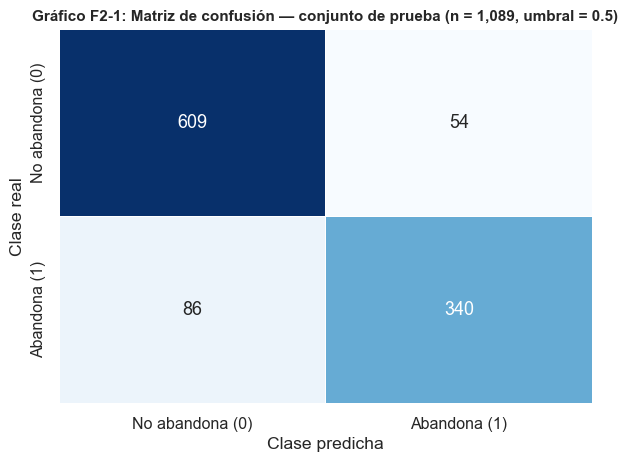

VN =  609 | FP =   54
FN =   86 | VP =  340

De los 426 desertores reales del test, el modelo detecta 340 (79.8%) y deja pasar 86 (20.2%, falsos negativos).


In [13]:
# ============================================================
# PREDICCIONES SOBRE TEST + MATRIZ DE CONFUSIÓN
# ============================================================
UMBRAL = 0.5
y_prob = modelo.predict(X_test_c)          # probabilidades P(Abandono = 1)
y_pred = (y_prob >= UMBRAL).astype(int)    # clase predicha con umbral 0,5

cm = confusion_matrix(y_test, y_pred)      # filas = real, columnas = predicho
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6.2, 4.8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["No abandona (0)", "Abandona (1)"],
            yticklabels=["No abandona (0)", "Abandona (1)"],
            annot_kws={"size": 13}, linewidths=0.6, linecolor="white", ax=ax)
ax.set_xlabel("Clase predicha")
ax.set_ylabel("Clase real")
ax.set_title(f"Gráfico F2-1: Matriz de confusión — conjunto de prueba "
             f"(n = {len(y_test):,}, umbral = {UMBRAL})", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"VN = {tn:4d} | FP = {fp:4d}")
print(f"FN = {fn:4d} | VP = {tp:4d}")
print(f"\nDe los {tp+fn} desertores reales del test, el modelo detecta {tp} "
      f"({tp/(tp+fn):.1%}) y deja pasar {fn} ({fn/(tp+fn):.1%}, falsos negativos).")

<a id='5.2-metricas'></a>
### 5.2 Métricas: accuracy, precision, recall y F1

Cada métrica responde una pregunta distinta del problema:

- **Accuracy** — proporción total de aciertos. Útil como panorama, pero puede engañar con clases desbalanceadas
  (aquí el desbalance es moderado: 39% / 61%).
- **Precision** — de los estudiantes que el modelo marca en riesgo, ¿qué fracción realmente abandona? Gobierna el
  costo de intervenir de más.
- **Recall (sensibilidad)** — de los que realmente abandonan, ¿qué fracción detecta el modelo? Es la métrica
  **prioritaria en un sistema de alerta temprana**, porque el falso negativo es el error más costoso.
- **F1** — media armónica de precision y recall; resume el balance entre ambos errores.


In [14]:
# ============================================================
# MÉTRICAS DE DESEMPEÑO — conjunto de prueba
# ============================================================
metricas = pd.DataFrame({
    "Métrica": ["Accuracy", "Precision", "Recall (sensibilidad)", "F1-score"],
    "Valor": [accuracy_score(y_test, y_pred),
              precision_score(y_test, y_pred),
              recall_score(y_test, y_pred),
              f1_score(y_test, y_pred)],
    "Pregunta que responde": [
        "¿Qué % del total clasifica bien?",
        "De los marcados en riesgo, ¿qué % abandona realmente?",
        "De los que abandonan, ¿qué % detecta el modelo?",
        "Balance armónico precision-recall",
    ],
})
display(metricas.round(4))

# Baseline ingenuo: predecir siempre la clase mayoritaria (nadie abandona)
acc_baseline = max(1 - y_test.mean(), y_test.mean())
print(f"Baseline (predecir siempre 'No abandona'): accuracy = {acc_baseline:.4f}, "
      f"pero recall = 0 (no detectaría a NINGÚN desertor).")
print("El modelo debe superar ese baseline en accuracy y, sobre todo, entregar recall útil.")
print("\nReporte por clase:")
print(classification_report(y_test, y_pred,
                            target_names=["No abandona (0)", "Abandona (1)"], digits=4))

,Métrica,Valor,Pregunta que responde
0,Accuracy,0.8714,¿Qué % del total clasifica bien?
1,Precision,0.8629,"De los marcados en riesgo, ¿qué % abandona rea..."
2,Recall (sensibilidad),0.7981,"De los que abandonan, ¿qué % detecta el modelo?"
3,F1-score,0.8293,Balance armónico precision-recall


Baseline (predecir siempre 'No abandona'): accuracy = 0.6088, pero recall = 0 (no detectaría a NINGÚN desertor).
El modelo debe superar ese baseline en accuracy y, sobre todo, entregar recall útil.

Reporte por clase:
                 precision    recall  f1-score   support

No abandona (0)     0.8763    0.9186    0.8969       663
   Abandona (1)     0.8629    0.7981    0.8293       426

       accuracy                         0.8714      1089
      macro avg     0.8696    0.8583    0.8631      1089
   weighted avg     0.8711    0.8714    0.8704      1089



**Interpretación contextual.** El modelo supera con claridad el baseline ingenuo y —a diferencia de él— detecta
una fracción sustantiva de los desertores reales. En un sistema de alerta temprana la lectura práctica es:

- Una **precision** en torno al valor obtenido significa que la mayoría de los estudiantes contactados por el sistema
  efectivamente estaba en riesgo → los recursos de apoyo (tutorías, ayuda financiera) se focalizan bien.
- Un **recall** en torno al valor obtenido implica que una parte de los desertores no es detectada con el umbral 0,5.
  Dado que el FN es el error más costoso, para el despliegue real convendría **bajar el umbral** (p. ej. a 0,35–0,40),
  sacrificando algo de precision para ganar recall — decisión de negocio que se explora formalmente con la curva ROC.
- El desempeño con solo 5 variables **conocidas al final del primer semestre** confirma la recomendación de S2:
  el rendimiento temprano más la situación financiera bastan para una alerta accionable, sin esperar datos del
  segundo semestre.


<a id='5.3-roc'></a>
### 5.3 Curva ROC y AUC

La curva ROC grafica la tasa de verdaderos positivos (recall) contra la tasa de falsos positivos **para todos los
umbrales posibles**; el AUC (área bajo la curva) resume la capacidad discriminante: es la probabilidad de que el
modelo asigne mayor riesgo a un desertor real que a un graduado tomados al azar. Rangos de referencia usuales:

| AUC | Interpretación |
|:---|:---|
| 0,5 | Sin capacidad discriminante (azar) |
| 0,6 – 0,7 | Pobre |
| 0,7 – 0,8 | Aceptable |
| 0,8 – 0,9 | **Buena / excelente** |
| > 0,9 | Sobresaliente |


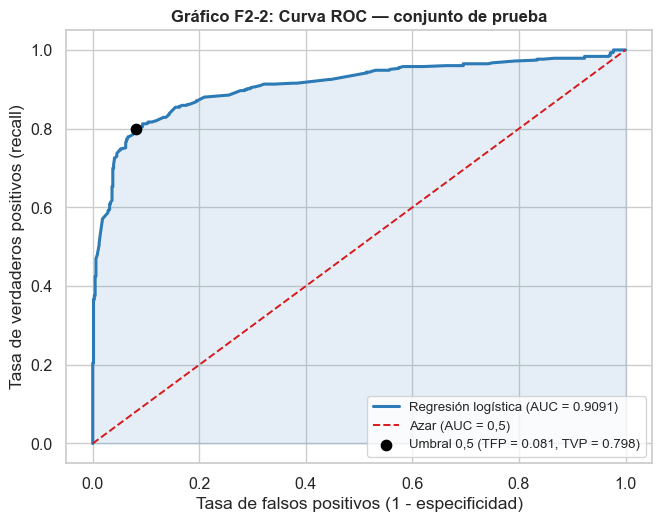

AUC = 0.9091 → discriminación SOBRESALIENTE según los rangos de referencia.
Lectura: si se toma al azar un desertor y un graduado del test, el modelo asigna
mayor probabilidad de abandono al desertor el 90.9% de las veces.


In [15]:
# ============================================================
# CURVA ROC + AUC — conjunto de prueba
# ============================================================
fpr, tpr, umbrales = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

# Punto de operación del umbral 0,5 sobre la curva
idx_05 = np.argmin(np.abs(umbrales - UMBRAL))

fig, ax = plt.subplots(figsize=(6.8, 5.4))
ax.plot(fpr, tpr, color="#2C7BB6", lw=2.2, label=f"Regresión logística (AUC = {auc:.4f})")
ax.plot([0, 1], [0, 1], color="#D7191C", ls="--", lw=1.4, label="Azar (AUC = 0,5)")
ax.fill_between(fpr, tpr, alpha=0.12, color="#2C7BB6")
ax.scatter(fpr[idx_05], tpr[idx_05], color="black", zorder=5, s=55,
           label=f"Umbral 0,5 (TFP = {fpr[idx_05]:.3f}, TVP = {tpr[idx_05]:.3f})")
ax.set_xlabel("Tasa de falsos positivos (1 - especificidad)")
ax.set_ylabel("Tasa de verdaderos positivos (recall)")
ax.set_title("Gráfico F2-2: Curva ROC — conjunto de prueba", fontsize=12, fontweight="bold")
ax.legend(loc="lower right", fontsize=9.5)
plt.tight_layout()
plt.show()

rangos = [(0.9, "SOBRESALIENTE"), (0.8, "BUENA/EXCELENTE"), (0.7, "ACEPTABLE"),
          (0.6, "POBRE"), (0.0, "SIN CAPACIDAD DISCRIMINANTE")]
categoria = next(nombre for corte, nombre in rangos if auc >= corte)
print(f"AUC = {auc:.4f} → discriminación {categoria} según los rangos de referencia.")
print(f"Lectura: si se toma al azar un desertor y un graduado del test, el modelo asigna")
print(f"mayor probabilidad de abandono al desertor el {auc:.1%} de las veces.")

**Interpretación.** El AUC obtenido (≈ 0,91) sitúa al modelo en la franja **sobresaliente** de los rangos de
referencia: con solo cinco predictores tempranos, discrimina correctamente el orden de riesgo en cerca del 91% de los
pares desertor–graduado. La curva además muestra que existen puntos de operación con recall considerablemente mayor al del
umbral 0,5 a cambio de un aumento moderado de falsos positivos — información directamente accionable para calibrar el
umbral del sistema de alerta en S3 según el costo relativo FN/FP.


<a id='6-sintesis'></a>
## 6. Síntesis y reflexión

**Cómo se integraron S1 y S2 en el modelamiento.** Este notebook no partió de cero: cada decisión ancló en evidencia
previa. De **S1** se heredaron (i) el dataset binario y sus criterios (n = 3.630, Graduate/Dropout), (ii) la
verificación de ausencia de valores faltantes —re-validada aquí, lo que hizo innecesaria la imputación—, (iii) los
contrastes que identificaron a `Curricular units 1st sem (approved)` como el predictor dominante (d = 1,37) y a las
variables financieras como el mejor bloque categórico (V de Cramér 0,27–0,44), y (iv) la matriz de correlaciones que
alertó de la colinealidad del bloque de rendimiento. De **S2** se tomaron las validaciones que convierten esos
hallazgos en insumos confiables: parámetros robustos por bootstrap, contrastes confirmados por permutación (incluido
el no-rechazo que justificó excluir las macroeconómicas), la estabilidad de las correlaciones (que confirmó tanto la
colinealidad como el efecto débil-pero-real de la edad), y el análisis de robustez que ordenó **conservar los
outliers** (las notas 0 son el fenómeno, no ruido). La selección final de 5 variables ejecutó literalmente la
recomendación S2 §8: una sola variable de rendimiento + bloque financiero + edad, lo que el VIF (< 5 en todas)
confirmó como acertado.

**Evaluación del desempeño.** El modelo es globalmente significativo (LR test, p ≈ 0) y todos los predictores
resultaron individualmente significativos con signos coherentes con S1/S2. La selección no se dio por buena a priori:
se sometió a **competencia formal** contra cuatro alternativas mediante AIC/BIC (4.4) y **validación cruzada 5-fold
estratificada solo en train** (4.5), consolidando ambos análisis en tablas comparativas únicas. El veredicto fue
nítido: los modelos parciales (solo académico, solo financiero) quedan descartados con evidencia muy fuerte (Δ ≫ 10);
quitar la edad también empeora ambos criterios con evidencia muy fuerte (ΔAIC ≈ 46) y reduce el AUC de CV; y añadir
`grade` — pese a un AIC marginalmente mejor — no aporta capacidad de generalización (ΔAUC de CV ≈ 0,001, menor que la
variabilidad entre folds) y reintroduce colinealidad; por parsimonia se confirmó el modelo de 5 variables. Sobre el test (30% estratificado, jamás usado en ninguna
decisión), supera con holgura el baseline ingenuo (accuracy ≈ 0,87 vs. 0,61) y alcanza un AUC ≈ 0,91, en la franja
sobresaliente: cinco variables disponibles al final del primer semestre bastan para ordenar el riesgo de abandono con
calidad accionable. La principal limitación con el umbral 0,5 es el recall (≈ 0,80): uno de cada cinco desertores
queda sin detectar, y en este problema el falso negativo es el error más costoso.

**Mejoras metodológicas de cara a la Sumativa 3.**
1. **Calibrar el umbral de decisión** con la curva ROC (o curvas precision-recall) según el costo relativo FN/FP,
   en lugar de asumir 0,5 — la curva de 5.3 ya muestra puntos de operación con mayor recall a costo moderado.
2. **Ampliar el espacio de candidatos** en la comparación AIC/BIC + CV ya montada en 4.4–4.5: incorporar el indicador
   binario "sin evaluaciones" recomendado en S2 §8, y usar métodos stepwise como guía exploratoria —no mecánica—.
3. **Diagnóstico ampliado**: observaciones influyentes sobre el modelo logístico y análisis de sensibilidad de los
   coeficientes ante distintas particiones y semillas.
4. **Explorar interacciones** con justificación sustantiva (p. ej., Debtor × Tuition fees) cuidando el sobreajuste, y
   evaluar regularización (Ridge/Lasso con CV) si crece el número de predictores.


<a id='7-referencias'></a>
## 7. Referencias

- Maidana, J. P. (2026a). *Fundamentos de aprendizaje supervisado* [Apunte]. Universidad Andrés Bello, Santiago, Chile.
- Maidana, J. P. (2026b). *Preparación de datos para modelamiento* [Apunte]. Universidad Andrés Bello, Santiago, Chile.
- Maidana, J. P. (2026d). *Selección de variables y comparación de modelos* [Apunte]. Universidad Andrés Bello, Santiago, Chile.
- Maidana, J. P. (2026e). *Diagnóstico de supuestos del modelo* [Apunte]. Universidad Andrés Bello, Santiago, Chile.
- James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An introduction to statistical learning* (2nd ed.). Springer.
- Pedregosa, F., et al. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.
- Realinho, V., Machado, J., Baptista, L., & Martins, M. V. (2021). *Predict Students' Dropout and Academic Success*
  [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5MC89
- Grupo 7 (2026). *Sumativa 1 — Informe: Análisis exploratorio e inferencial del abandono académico* y
  *Sumativa 2 — Informe 3: Validación, simulación y métodos de remuestreo*. MCDI501, UNAB.
